<a href="https://www.kaggle.com/code/mykolarekunenko/notebook-hw-2?scriptVersionId=293385608" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Завдання:
Ознайомитись з даними та структурою даних
Створіть доповнення(transform) для тренувальних та тестових даних. посилання
Створіть train_dataset та test_dataset за допомогою ImageFolder(папка train)
Переконайтесь що у вас привильні назви класів
Створіть DataLoader для тренувальних та тестових даних
Візуалізуйте дані
Збережіть kaggle notebook для подальшої роботи

In [76]:
import torch
from torchvision import datasets, transforms

In [77]:
data_dir = "/kaggle/input/fruit-recognition/train/train"
# Створюємо екземпляр ImageFolder
all_dataset = datasets.ImageFolder(data_dir)

In [78]:
all_dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [83]:
data_train, data_test = torch.utils.data.random_split(all_dataset, [0.8, 0.2])

In [84]:
len(all_dataset), len(data_train), len(data_test)

(16854, 13484, 3370)

In [89]:
train_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
    transforms.RandomRotation(180),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor()
    ]
)

In [90]:
test_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
     transforms.ToTensor()
    ]
)

In [91]:
train_data = TransformDataset(data_train, train_transform)

In [92]:
test_data = TransformDataset(data_test, test_transform)

In [93]:
train_loader = DataLoader(train_data, batch_size=256)

In [94]:
test_loader = DataLoader(test_data, batch_size=256)

In [95]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape)

torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([42, 3, 224, 224])
torch.Size([42])


(224, 224, 3)


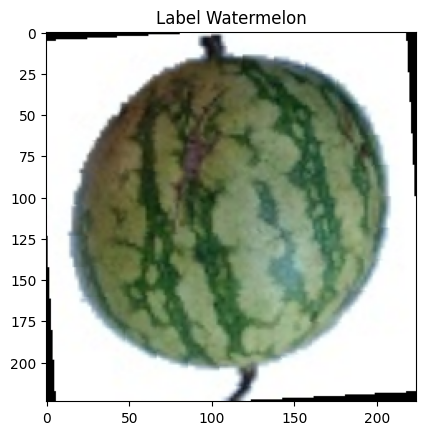

(224, 224, 3)


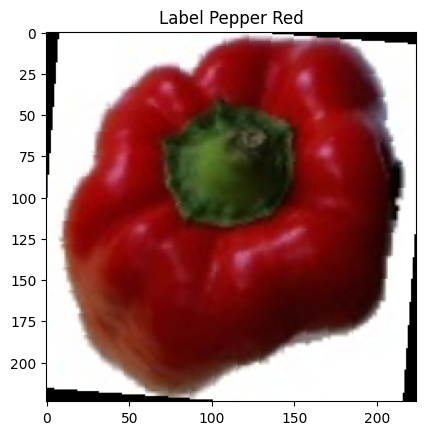

(224, 224, 3)


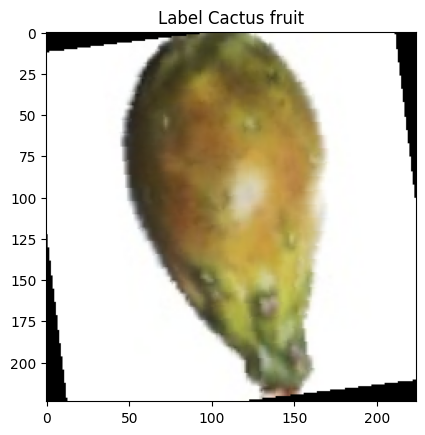

In [96]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = all_dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

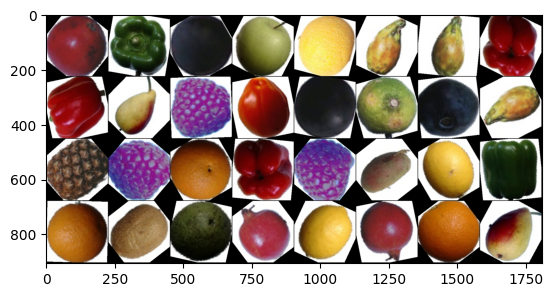

In [97]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)